#Mount Drive, Import Libraries, Import Models

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as res_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as dense_preprocess
from tensorflow.keras.preprocessing import image as keras_image

BASE    = '/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/final project/Freshwater Fish Disease Aquaculture in south asia'
CLS_DIR = BASE + '/Models_Fish_Classification'
DIS_DIR = BASE + '/Models_Disease_Classification'

# Species models
print('Loading species models...')
eff_species   = load_model(f'{CLS_DIR}/FishClass_EfficientNet_98.keras')
res_species   = load_model(f'{CLS_DIR}/FishClass_ResNet50_99.keras')
dense_species = load_model(f'{CLS_DIR}/FishClass_DenseNet121_96.keras')
print('Species models loaded.')

# Disease models
print('Loading disease models...')
eff_disease   = load_model(f'{DIS_DIR}/fish_disease_EfficientNetB0_finetuned.keras')
res_disease   = load_model(f'{DIS_DIR}/fish_disease_resnet50_finetuned.keras')
dense_disease = load_model(f'{DIS_DIR}/DenseNet121_FishDisease_finetuned_93.keras')
print('Disease models loaded.')

# Class names
species_classes = ['MilkFish', 'Tilapia']
disease_classes = [
    'Bacterial Red disease',
    'Bacterial gill disease',
    'Fungal diseases Saprolegniasis',
    'Healthy'
]

# Preprocessing map
preprocess_map = {
    'efficientnet': eff_preprocess,
    'resnet':       res_preprocess,
    'densenet':     dense_preprocess,
}

print('\nAll models ready.')

Loading species models...
Species models loaded.
Loading disease models...
Disease models loaded.

All models ready.


#  Pipeline Function & Pipeline Definitions

In [16]:
def run_pipeline(img_array, species_model, disease_model,
                 species_backbone, disease_backbone):
    """
    Runs a two-stage sequential pipeline on a single image.

    Parameters
    ----------
    img_array        : np.ndarray, shape (1, 224, 224, 3), raw pixel values (0-255)
    species_model    : Stage 1 Keras model
    disease_model    : Stage 2 Keras model
    species_backbone : str — 'efficientnet' | 'resnet' | 'densenet'
    disease_backbone : str — 'efficientnet' | 'resnet' | 'densenet'

    Returns
    -------
    dict with species prediction, disease prediction, and confidence scores
    """
    # Stage 1: Identify species
    img_s        = preprocess_map[species_backbone](img_array.copy())
    species_pred = species_model.predict(img_s, verbose=0)
    species_idx  = np.argmax(species_pred)
    species_conf = float(np.max(species_pred))

    # Stage 2: Diagnose disease
    img_d        = preprocess_map[disease_backbone](img_array.copy())
    disease_pred = disease_model.predict(img_d, verbose=0)
    disease_idx  = np.argmax(disease_pred)
    disease_conf = float(np.max(disease_pred))

    return {
        'species':      species_classes[species_idx],
        'species_conf': species_conf,
        'disease':      disease_classes[disease_idx],
        'disease_conf': disease_conf,
        'joint_conf':   species_conf * disease_conf,
    }


# Pipeline definitions
# Each entry: (display name, species_model, disease_model, species_backbone, disease_backbone)
pipelines = [
    ('EfficientNet → ResNet',   eff_species,   res_disease,   'efficientnet', 'resnet'),
    ('EfficientNet → DenseNet', eff_species,   dense_disease, 'efficientnet', 'densenet'),
    ('ResNet → EfficientNet',   res_species,   eff_disease,   'resnet',       'efficientnet'),
    ('ResNet → DenseNet',       res_species,   dense_disease, 'resnet',       'densenet'),
    ('DenseNet → EfficientNet', dense_species, eff_disease,   'densenet',     'efficientnet'),
    ('DenseNet → ResNet',       dense_species, res_disease,   'densenet',     'resnet'),
]

print(f'{len(pipelines)} pipelines defined.')

6 pipelines defined.


# Batch Evaluation Function

In [17]:
def evaluate_pipeline_on_dataset(species_model, disease_model,
                                  species_backbone, disease_backbone,
                                  val_data):
    """
    Evaluates a pipeline on the full validation dataset.

    Parameters
    ----------
    val_data : tf.data.Dataset
        Must yield (raw_images, disease_one_hot_labels).
        Images must be RAW (0-255), not preprocessed.

    Returns
    -------
    report         : dict  — sklearn classification report
    cm             : array — confusion matrix
    species_preds  : list  — Stage 1 predicted class indices
    disease_preds  : list  — Stage 2 predicted class indices
    disease_true   : list  — ground truth disease class indices
    species_confs  : list  — Stage 1 confidence scores
    disease_confs  : list  — Stage 2 confidence scores
    joint_confs    : list  — product of both confidence scores
    """
    all_species_preds = []
    all_disease_preds = []
    all_disease_true  = []
    all_species_confs = []
    all_disease_confs = []
    all_joint_confs   = []

    for images, labels in val_data:
        for i in range(len(images)):
            img = images[i].numpy()
            img = np.expand_dims(img, axis=0)  # (1, 224, 224, 3)

            # Stage 1: Species
            img_s = preprocess_map[species_backbone](img.copy())
            sp    = species_model.predict(img_s, verbose=0)
            all_species_preds.append(int(np.argmax(sp)))
            all_species_confs.append(float(np.max(sp)))

            # Stage 2: Disease
            img_d = preprocess_map[disease_backbone](img.copy())
            dp    = disease_model.predict(img_d, verbose=0)
            all_disease_preds.append(int(np.argmax(dp)))
            all_disease_confs.append(float(np.max(dp)))

            all_joint_confs.append(float(np.max(sp)) * float(np.max(dp)))

        all_disease_true.extend(np.argmax(labels.numpy(), axis=1).tolist())

    all_disease_preds = np.array(all_disease_preds)
    all_disease_true  = np.array(all_disease_true)

    report = classification_report(
        all_disease_true, all_disease_preds,
        target_names=disease_classes,
        output_dict=True,
        zero_division=0
    )
    cm = confusion_matrix(all_disease_true, all_disease_preds)

    return (report, cm,
            all_species_preds, all_disease_preds, all_disease_true,
            all_species_confs, all_disease_confs, all_joint_confs)

print('Evaluation function ready.')

Evaluation function ready.


In [18]:
from sklearn.metrics import accuracy_score

def get_species_accuracy(species_model, backbone, species_data):
    """Runs only the species model on the FreshWaterFishClasses dataset."""
    all_preds = []
    all_true = []

    for images, labels in species_data:
        for i in range(len(images)):
            img = images[i].numpy()
            img = np.expand_dims(img, axis=0)

            # Preprocess and predict
            img_s = preprocess_map[backbone](img.copy())
            sp = species_model.predict(img_s, verbose=0)

            all_preds.append(int(np.argmax(sp)))

        # Get true labels from the batch
        all_true.extend(np.argmax(labels.numpy(), axis=1).tolist())

    return accuracy_score(all_true, all_preds)

# Run All Pipelines in Validation Set

In [19]:
val_disease_data = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/final project/Freshwater Fish Disease Aquaculture in south asia/FreshWaterFishDiseases/Test",
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical',
    shuffle=False
)

val_species_data = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/final project/Freshwater Fish Disease Aquaculture in south asia/FreshWaterFishClasses/Test",
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical',
    shuffle=False
)
results_summary  = []
pipeline_outputs = {}

for name, sm, dm, sb, db in pipelines:
    print(f'\nRunning pipeline: {name} ...')


    species_acc = get_species_accuracy(sm, sb, val_species_data)
    (report, cm,
     sp_preds, dp_preds, dp_true,
     sp_confs, dp_confs, jt_confs) = evaluate_pipeline_on_dataset(
        sm, dm, sb, db, val_disease_data
    )

    pipeline_outputs[name] = {
        'report':        report,
        'cm':            cm,
        'disease_preds': dp_preds,
        'disease_true':  dp_true,
        'species_confs': sp_confs,   # add this
        'joint_confs':   jt_confs,   # add this
    }

    results_summary.append({
        'Pipeline':         name,
        'Species Accuracy': round(species_acc, 4),
        'Disease Accuracy': round(report['accuracy'], 4),
        'Macro F1':         round(report['macro avg']['f1-score'], 4),
        'Macro Precision':  round(report['macro avg']['precision'], 4),
        'Macro Recall':     round(report['macro avg']['recall'], 4),
        'Mean Joint Conf':  round(float(np.mean(jt_confs)), 4),
    })

    print(f'  Species Acc: {species_acc:.4f} | Disease Acc: {report["accuracy"]:.4f} | Macro F1: {report["macro avg"]["f1-score"]:.4f}')

    # para di mag out off ram
    tf.keras.backend.clear_session()

results_df = pd.DataFrame(results_summary).sort_values('Disease Accuracy', ascending=False)
print('\n=== Pipeline Comparison Summary ===')
results_df

Found 72 files belonging to 4 classes.
Found 72 files belonging to 2 classes.

Running pipeline: EfficientNet → ResNet ...
  Species Acc: 0.9861 | Disease Acc: 0.9583 | Macro F1: 0.9530

Running pipeline: EfficientNet → DenseNet ...
  Species Acc: 0.9861 | Disease Acc: 0.9306 | Macro F1: 0.9282

Running pipeline: ResNet → EfficientNet ...
  Species Acc: 0.9861 | Disease Acc: 0.9583 | Macro F1: 0.9530

Running pipeline: ResNet → DenseNet ...
  Species Acc: 0.9861 | Disease Acc: 0.9306 | Macro F1: 0.9282

Running pipeline: DenseNet → EfficientNet ...
  Species Acc: 0.9583 | Disease Acc: 0.9583 | Macro F1: 0.9530

Running pipeline: DenseNet → ResNet ...
  Species Acc: 0.9583 | Disease Acc: 0.9583 | Macro F1: 0.9530

=== Pipeline Comparison Summary ===


,Pipeline,Species Accuracy,Disease Accuracy,Macro F1,Macro Precision,Macro Recall,Mean Joint Conf
0,EfficientNet → ResNet,0.9861,0.9583,0.9530,0.9569,0.9507,0.8751
2,ResNet → EfficientNet,0.9861,0.9583,0.9530,0.9569,0.9507,0.8717
5,DenseNet → ResNet,0.9583,0.9583,0.9530,0.9569,0.9507,0.8432
4,DenseNet → EfficientNet,0.9583,0.9583,0.9530,0.9569,0.9507,0.8350
1,EfficientNet → DenseNet,0.9861,0.9306,0.9282,0.9679,0.9052,0.8633
3,ResNet → DenseNet,0.9861,0.9306,0.9282,0.9679,0.9052,0.8653


# Confidence Test

In [35]:
import os, random

# ── Paths ──────────────────────────────────────────────────────────────────────
DISEASE_ROOT      = '/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/final project/Freshwater Fish Disease Aquaculture in south asia/FreshWaterFishDiseases/Test'
SPECIES_ROOT      = '/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/final project/Freshwater Fish Disease Aquaculture in south asia/FreshWaterFishClasses/Test'

SAMPLES_PER_CLASS = 5
VALID_EXTS        = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
SEEDS_TO_TRY      = 10   # how many seeds to search over

def sample_class_dir(root, n=SAMPLES_PER_CLASS, seed=None):
    rng = random.Random(seed)
    class_samples = {}
    if not os.path.isdir(root):
        print(f'[WARN] Directory not found: {root}')
        return class_samples
    for cls in sorted(os.listdir(root)):
        cls_dir = os.path.join(cls_dir := os.path.join(root, cls), '')
        cls_dir = os.path.join(root, cls)
        if not os.path.isdir(cls_dir):
            continue
        imgs = [
            os.path.join(cls_dir, f)
            for f in os.listdir(cls_dir)
            if os.path.splitext(f)[1].lower() in VALID_EXTS
        ]
        if not imgs:
            continue
        class_samples[cls] = rng.sample(imgs, min(n, len(imgs)))
    return class_samples

def run_confidence_test(seed):
    disease_samples = sample_class_dir(DISEASE_ROOT, seed=seed)
    species_samples = sample_class_dir(SPECIES_ROOT, seed=seed)
    rows = []
    for domain, class_samples in [('Disease', disease_samples), ('Species', species_samples)]:
        for true_label, img_paths in class_samples.items():
            for img_path in img_paths:
                img     = keras_image.load_img(img_path, target_size=(224, 224))
                img_arr = keras_image.img_to_array(img)
                img_arr = np.expand_dims(img_arr, axis=0)
                for name, sm, dm, sb, db in pipelines:
                    result = run_pipeline(img_arr, sm, dm, sb, db)
                    rows.append({
                        'Pipeline':          name,
                        'Domain':            domain,
                        'True Label':        true_label,
                        'Predicted Species': result['species'],
                        'Species Conf':      round(result['species_conf'], 4),
                        'Predicted Disease': result['disease'],
                        'Disease Conf':      round(result['disease_conf'], 4),
                        'Joint Conf':        round(result['joint_conf'], 4),
                        'Correct':           (
                            result['disease'] == true_label if domain == 'Disease'
                            else result['species'] == true_label
                        ),
                    })
    return pd.DataFrame(rows), disease_samples, species_samples

def score_seed(df):
    """
    Higher = more variation across pipelines.
    Uses std of per-pipeline mean Joint Conf + std of per-pipeline accuracy.
    """
    per_pipeline = df.groupby('Pipeline').agg(
        mean_joint_conf=('Joint Conf', 'mean'),
        accuracy=('Correct', 'mean'),
    )
    return float(per_pipeline['mean_joint_conf'].std() + per_pipeline['accuracy'].std())

# ── Search over seeds ──────────────────────────────────────────────────────────
best_seed, best_score, best_df, best_disease_samples, best_species_samples = None, -1, None, None, None

for seed in range(SEEDS_TO_TRY):
    print(f'Testing seed {seed}/{SEEDS_TO_TRY - 1} ...', end='\r')
    df, ds, ss = run_confidence_test(seed)
    score = score_seed(df)
    if score > best_score:
        best_seed, best_score, best_df, best_disease_samples, best_species_samples = seed, score, df, ds, ss

print(f'\nBest seed : {best_seed}  (variation score: {best_score:.4f})')

# ── Finalise with best seed ────────────────────────────────────────────────────
conf_df = (
    best_df
    .sort_values(['Pipeline', 'Domain', 'True Label'])
    .reset_index(drop=True)
)

print('=== Confidence Test — Disease & Species Classes ===')
print(f'Disease classes : {sorted(best_disease_samples.keys())}')
print(f'Species classes : {sorted(best_species_samples.keys())}')
print(f'Samples/class   : {SAMPLES_PER_CLASS}')
print(f'Total rows      : {len(conf_df)}')
conf_df

OUTPUT_PATH = '/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/final project/confidence_test_results.xlsx'
conf_df.to_excel(OUTPUT_PATH, index=False)
print(f'Saved to {OUTPUT_PATH}')


Best seed : 3  (variation score: 0.0748)
=== Confidence Test — Disease & Species Classes ===
Disease classes : ['Bacterial Red disease', 'Bacterial gill disease', 'Fungal diseases Saprolegniasis', 'Healthy']
Species classes : ['MilkFish', 'Tilapia']
Samples/class   : 5
Total rows      : 180
Saved to /content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/final project/confidence_test_results.xlsx


# Error Propagation Analysis

In [36]:
propagation_rows = []

for name, outputs in pipeline_outputs.items():
    dp      = np.array(outputs['disease_preds'])
    dt      = np.array(outputs['disease_true'])
    sp_conf = np.array(outputs['species_confs'])
    jt_conf = np.array(outputs['joint_confs'])

    disease_wrong = (dp != dt)

    # Mean species confidence on wrong disease predictions
    # Low species confidence on errors suggests Stage 1 uncertainty propagated
    mean_sp_conf_on_errors = (
        float(np.mean(sp_conf[disease_wrong])) if disease_wrong.sum() > 0 else None
    )

    propagation_rows.append({
        'Pipeline':                      name,
        'Total Samples':                 len(dt),
        'Total Errors':                  int(disease_wrong.sum()),
        'Error Rate':                    round(float(disease_wrong.mean()), 4),
        'Mean Species Conf (Overall)':   round(float(np.mean(sp_conf)), 4),
        'Mean Species Conf (On Errors)': (
            round(mean_sp_conf_on_errors, 4) if mean_sp_conf_on_errors is not None else 'N/A'
        ),
        'Mean Joint Conf':               round(float(np.mean(jt_conf)), 4),
    })

prop_df = pd.DataFrame(propagation_rows).sort_values('Error Rate')
print('=== Error Propagation Analysis ===')
prop_df

=== Error Propagation Analysis ===


,Pipeline,Total Samples,Total Errors,Error Rate,Mean Species Conf (Overall),Mean Species Conf (On Errors),Mean Joint Conf
0,EfficientNet → ResNet,72,3,0.0417,0.9574,0.9942,0.8751
2,ResNet → EfficientNet,72,3,0.0417,0.9570,0.8943,0.8717
5,DenseNet → ResNet,72,3,0.0417,0.9210,0.9626,0.8432
4,DenseNet → EfficientNet,72,3,0.0417,0.9210,0.9626,0.8350
3,ResNet → DenseNet,72,5,0.0694,0.9570,0.8933,0.8653
1,EfficientNet → DenseNet,72,5,0.0694,0.9574,0.9668,0.8633


# Visualizations

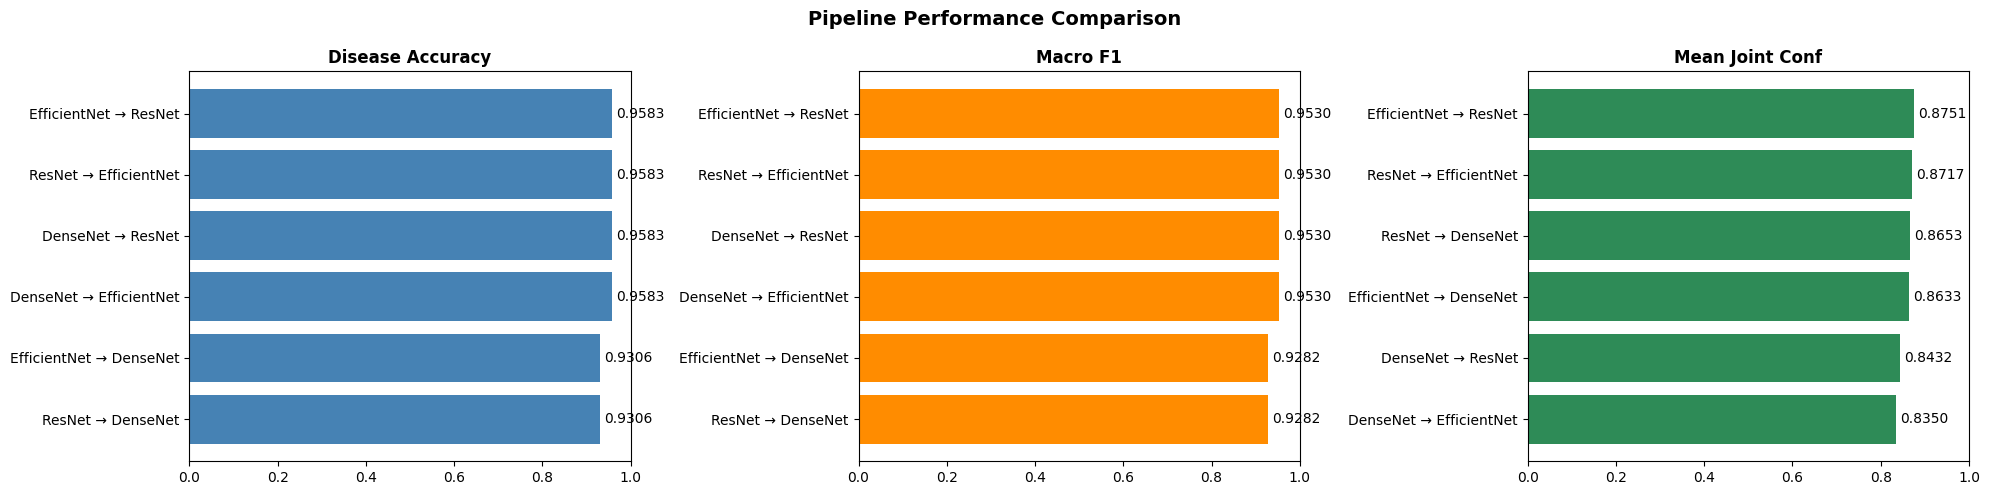

In [37]:
# ── Chart 1: Accuracy, Macro F1, Mean Joint Confidence ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

metrics = [
    ('Disease Accuracy', 'steelblue'),
    ('Macro F1',         'darkorange'),
    ('Mean Joint Conf',  'seagreen'),
]

for ax, (metric, color) in zip(axes, metrics):
    sorted_df = results_df.sort_values(metric, ascending=False)
    bars = ax.barh(sorted_df['Pipeline'], sorted_df[metric], color=color)
    ax.set_xlim(0, 1)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.bar_label(bars, fmt='%.4f', padding=3)
    ax.invert_yaxis()

plt.suptitle('Pipeline Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

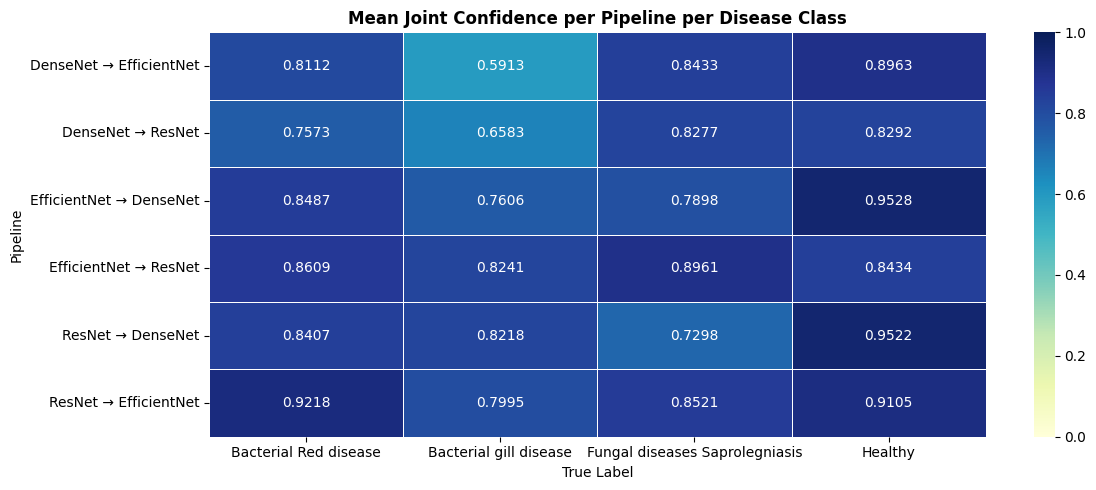

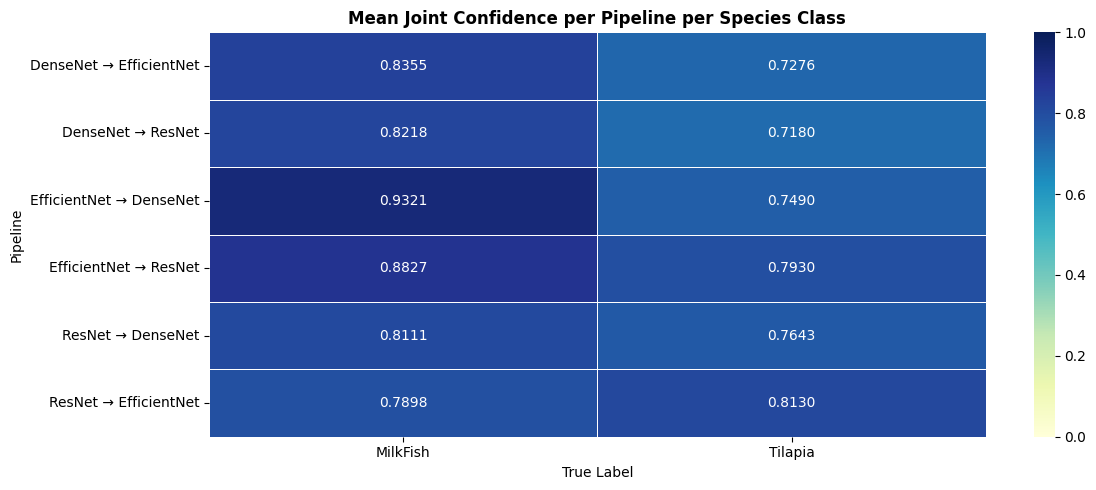

In [38]:
# ── Chart 2: Joint Confidence Heatmap ───────────────────────────────────────
for domain in ['Disease', 'Species']:
    subset = conf_df[conf_df['Domain'] == domain]

    pivot = subset.pivot_table(
        index='Pipeline', columns='True Label',
        values='Joint Conf', aggfunc='mean'
    )

    plt.figure(figsize=(12, 5))
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu',
                linewidths=0.5, vmin=0, vmax=1)
    plt.title(f'Mean Joint Confidence per Pipeline per {domain} Class',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

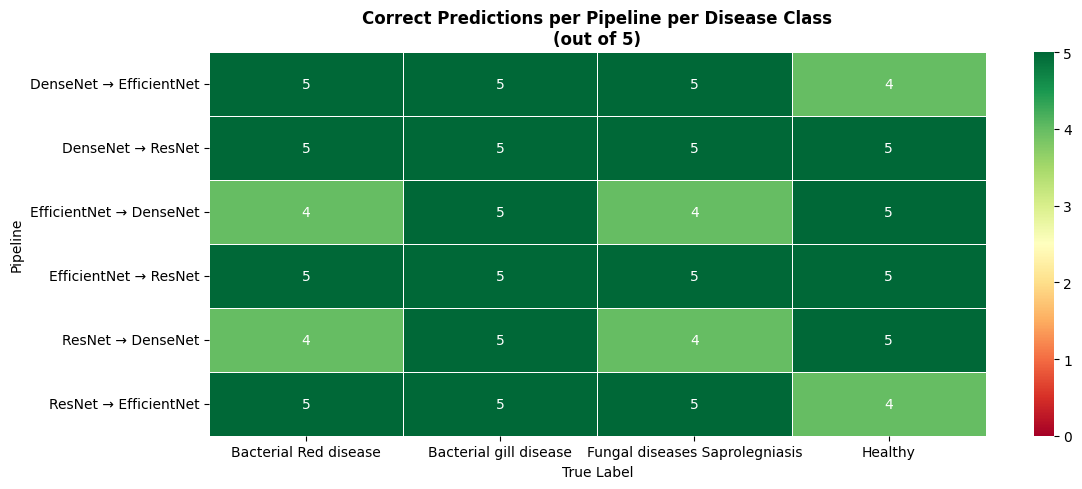

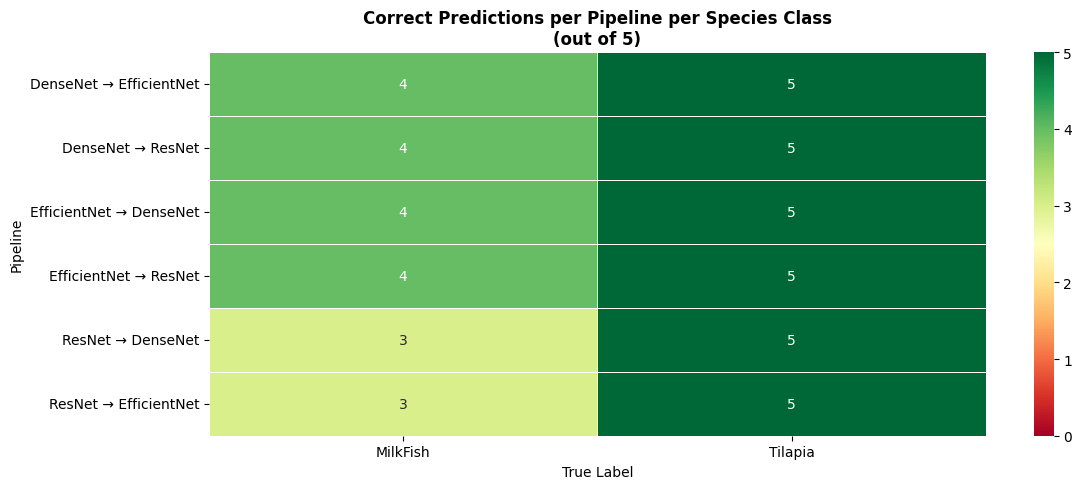

In [39]:
# ── Chart 3: Correctness per Pipeline ───────────────────────────────────────
for domain in ['Disease', 'Species']:
    subset = conf_df[conf_df['Domain'] == domain]

    correct_pivot = subset.pivot_table(
        index='Pipeline', columns='True Label',
        values='Correct', aggfunc='sum'
    )

    plt.figure(figsize=(12, 5))
    sns.heatmap(correct_pivot, annot=True, fmt='.0f', cmap='RdYlGn',
                linewidths=0.5, vmin=0, vmax=SAMPLES_PER_CLASS)
    plt.title(f'Correct Predictions per Pipeline per {domain} Class\n(out of {SAMPLES_PER_CLASS})',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

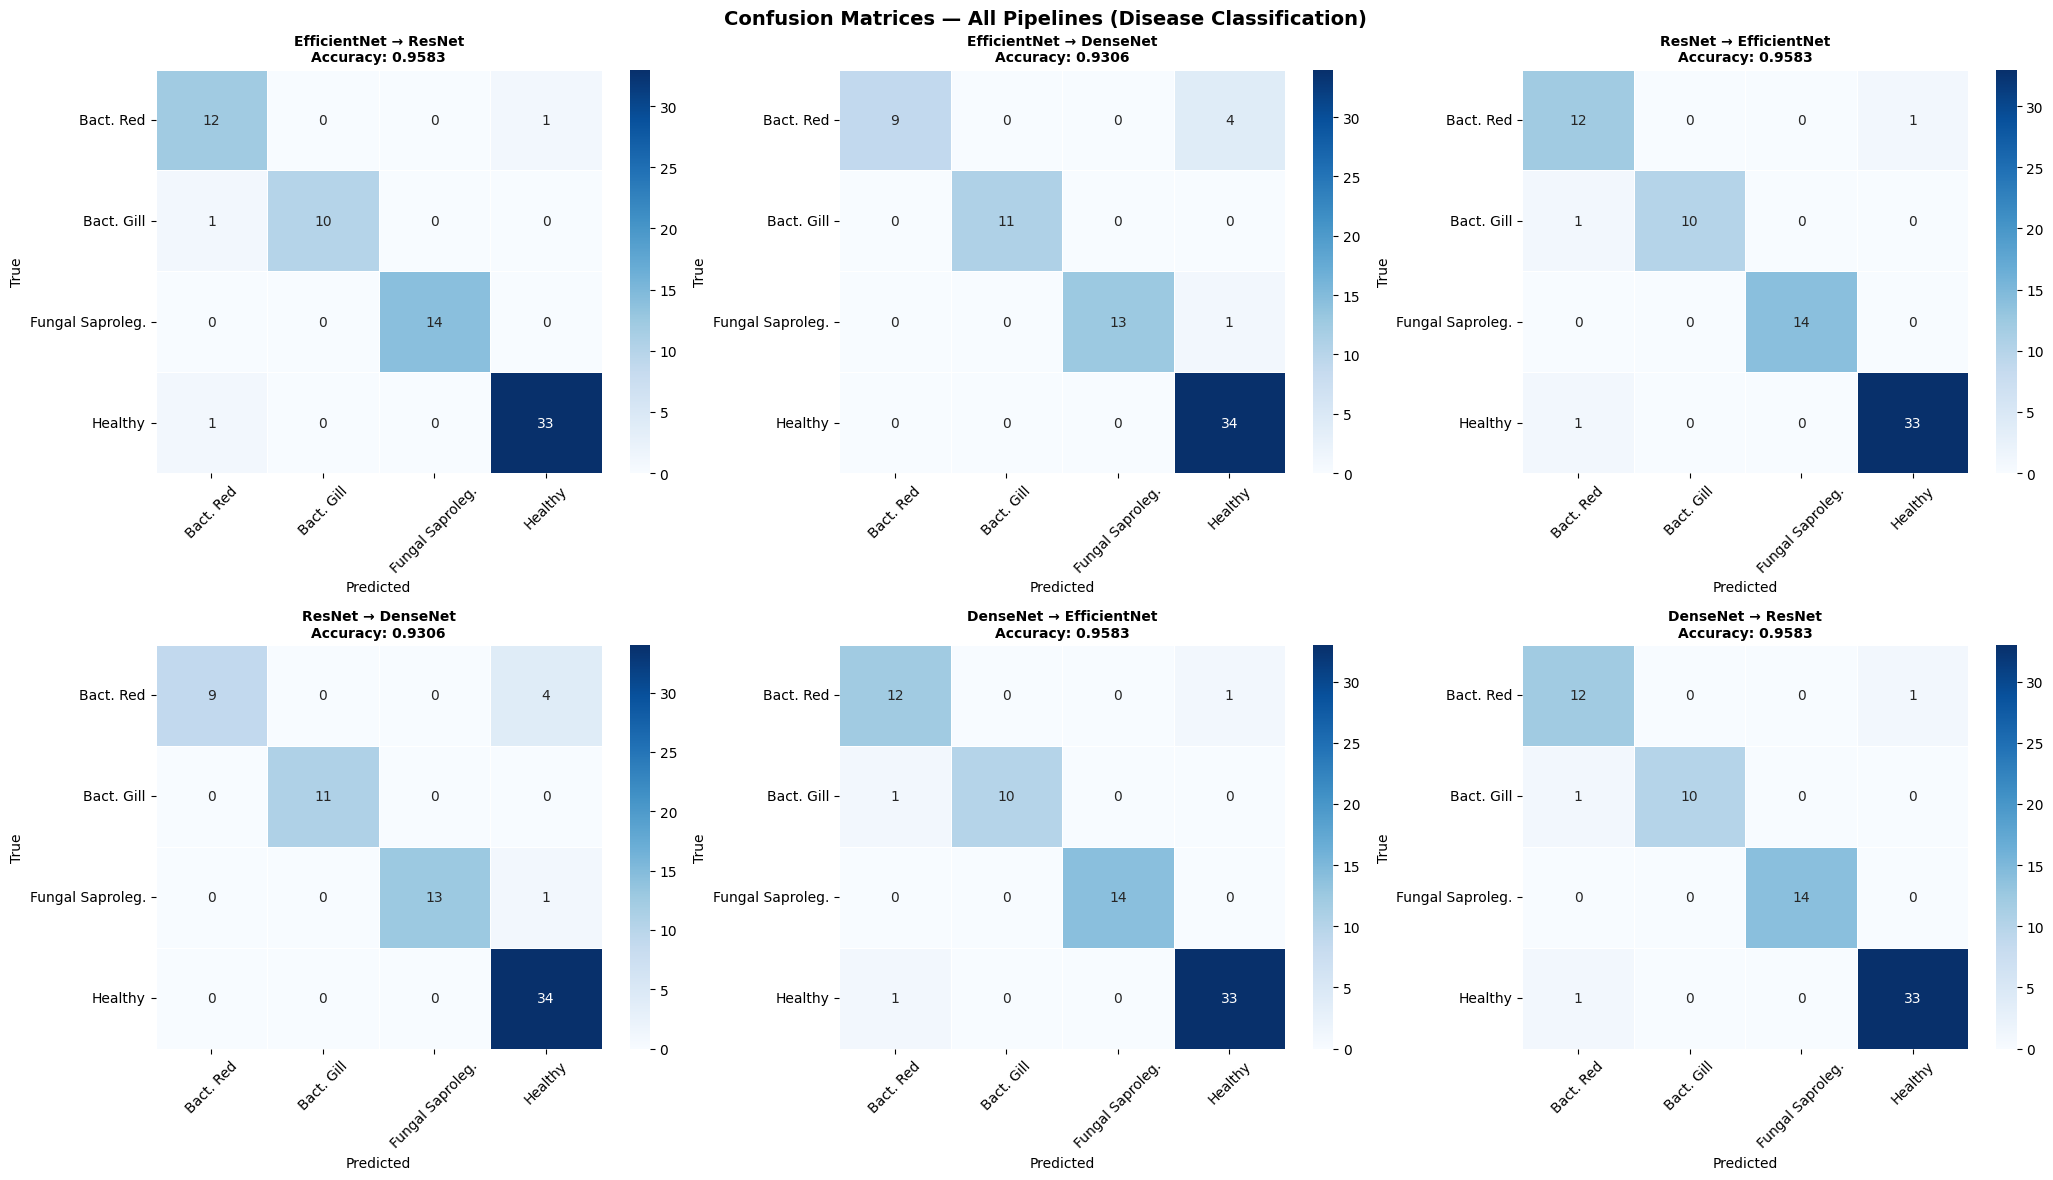

In [40]:
# ── Chart 4: Confusion Matrices for all pipelines ───────────────────────────
disease_classes = val_disease_data.class_names

# Shorten long class names for display
label_map = {c: c for c in disease_classes}  # identity by default
label_map.update({
    'Bacterial Red disease':          'Bact. Red',
    'Bacterial gill disease':         'Bact. Gill',
    'Fungal diseases Saprolegniasis': 'Fungal Saproleg.',
    'Healthy':                        'Healthy',
})
short_labels = [label_map.get(c, c) for c in disease_classes]

n_pipelines = len(pipeline_outputs)
n_cols      = 3
n_rows      = math.ceil(n_pipelines / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 6 * n_rows))
axes = axes.flatten()

for idx, (name, outputs) in enumerate(pipeline_outputs.items()):
    sns.heatmap(
        outputs['cm'], annot=True, fmt='d', ax=axes[idx],
        xticklabels=short_labels, yticklabels=short_labels,
        cmap='Blues', linewidths=0.5
    )
    acc = outputs['report']['accuracy']
    axes[idx].set_title(f'{name}\nAccuracy: {acc:.4f}', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].tick_params(axis='y', rotation=0)

for idx in range(n_pipelines, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Confusion Matrices — All Pipelines (Disease Classification)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.suptitle('Confusion Matrices — All Pipelines (Disease Classification)',
                 fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/final project/chart4_confusion_matrices.png',
                dpi=150, bbox_inches='tight')
plt.show()

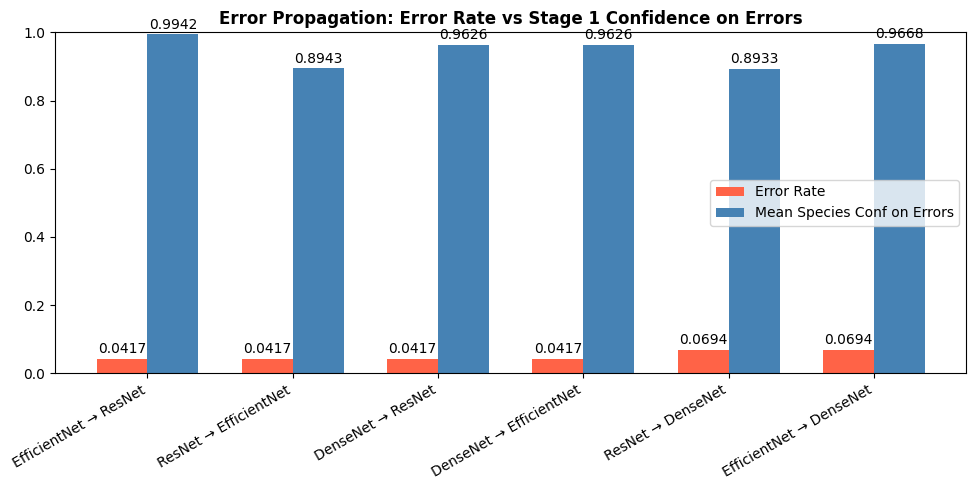

In [41]:
# ── Chart 5: Error Propagation — Error Rate vs Mean Species Confidence ───────
fig, ax = plt.subplots(figsize=(10, 5))

prop_plot = prop_df[prop_df['Mean Species Conf (On Errors)'] != 'N/A'].copy()
prop_plot['Mean Species Conf (On Errors)'] = prop_plot['Mean Species Conf (On Errors)'].astype(float)

x     = np.arange(len(prop_plot))
width = 0.35

bars1 = ax.bar(x - width/2, prop_plot['Error Rate'],
               width, label='Error Rate', color='tomato')
bars2 = ax.bar(x + width/2, prop_plot['Mean Species Conf (On Errors)'],
               width, label='Mean Species Conf on Errors', color='steelblue')

ax.set_xticks(x)
ax.set_xticklabels(prop_plot['Pipeline'], rotation=30, ha='right')
ax.set_ylim(0, 1)
ax.set_title('Error Propagation: Error Rate vs Stage 1 Confidence on Errors',
             fontsize=12, fontweight='bold')
ax.legend()
ax.bar_label(bars1, fmt='%.4f', padding=2)
ax.bar_label(bars2, fmt='%.4f', padding=2)

plt.tight_layout()
plt.show()